# Model Training & Evaluation

This notebook loads the processed dataset and trains multiple machine learning  
models to predict **30‑day hospital readmission** for diabetic patients.

We evaluate three models:

- Logistic Regression  
- Random Forest  
- XGBoost  

We compare accuracy, plot ROC curves, analyse feature importance, and save the  
best-performing model for deployment.

---

##  Load Processed Dataset

We load the cleaned and encoded dataset generated in the preprocessing notebook.


In [1]:
import pandas as pd


df = pd.read_csv("../data/processed/processed_diabetic_data.csv")

df.shape


(101766, 2431)

## Train/Test Split

We split the dataset into training and testing sets using an 80/20 split.  
Stratification ensures the target distribution remains consistent.


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted_30", axis=1)
y = df["readmitted_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y
)


##  Logistic Regression Model

We train a baseline Logistic Regression model and evaluate its performance.


In [3]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)


##  Random Forest Model

Random Forest captures non-linear relationships and interactions between features.


In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


## XGBoost Model

XGBoost is a powerful gradient boosting algorithm widely used in healthcare ML.


In [5]:
import platform
platform.architecture()


('64bit', 'Mach-O')

In [6]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


##  Compare Model Accuracy

We compare accuracy across all trained models to identify the strongest performer.


In [7]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))


Logistic Regression: 0.8882774884543578
Random Forest: 0.8887687923749632
XGBoost: 0.8891127051193869


##  ROC Curves for All Models

ROC curves show how well each model separates the two classes across different  
thresholds. We compute and plot ROC curves for all models.


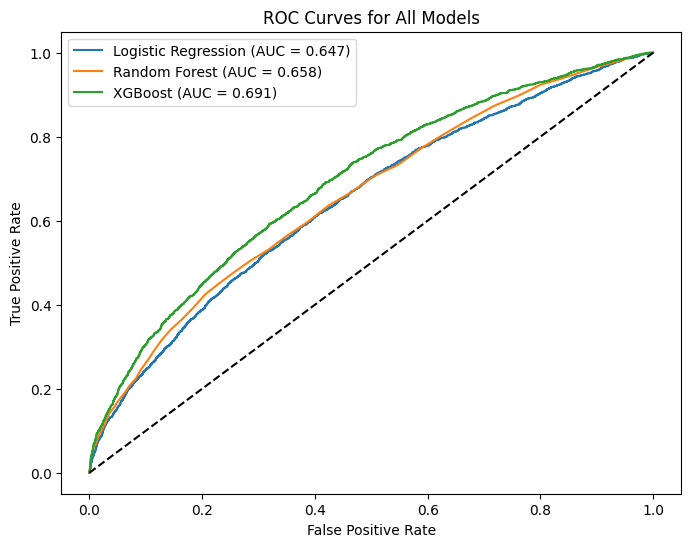

In [8]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr_probs = log_reg.predict_proba(X_test)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost (AUC = {xgb_auc:.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend()
plt.show()


## Feature Importance

We extract and display the top contributing features from Random Forest and XGBoost  
to understand which variables influence predictions the most.


In [9]:
import pandas as pd

rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)

rf_importance.sort_values(ascending=False).head(20)
xgb_importance.sort_values(ascending=False).head(20)


number_inpatient                                       0.017856
diag_1_V57                                             0.007590
discharge_disposition_id                               0.006809
diag_1_V58                                             0.004834
diag_2_410                                             0.004783
diag_1_250.11                                          0.004505
number_emergency                                       0.004476
medical_specialty_PhysicalMedicineandRehabilitation    0.004337
diag_1_434                                             0.004305
diag_1_348                                             0.004299
diag_3_397                                             0.004117
diag_2_342                                             0.004102
diag_3_511                                             0.003909
diag_1_537                                             0.003877
diag_3_790                                             0.003705
diag_3_250.6                            

##  Save Best Model

We save the XGBoost model for future use (deployment, API, or Power BI integration).


In [10]:
import os
os.makedirs("../models", exist_ok=True)


In [11]:
import joblib
joblib.dump(xgb, "../models/xgb_readmission.pkl")


['../models/xgb_readmission.pkl']